### House Price Prediction

## 01 - Problem Understanding
#### We want to predict sales price of the house based on its characteristics

## 02 - Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

## 03 - Load Dataset

In [2]:
df = pd.read_csv('D:\\House Price Prediction-ML\\Artifacts\\Data\\train.csv')

In [3]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
df.shape

(2930, 82)

#### Input features - 81

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [6]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


## 04 - Understanding the dataset

In [7]:
df.columns.tolist()

['Order',
 'PID',
 'MS SubClass',
 'MS Zoning',
 'Lot Frontage',
 'Lot Area',
 'Street',
 'Alley',
 'Lot Shape',
 'Land Contour',
 'Utilities',
 'Lot Config',
 'Land Slope',
 'Neighborhood',
 'Condition 1',
 'Condition 2',
 'Bldg Type',
 'House Style',
 'Overall Qual',
 'Overall Cond',
 'Year Built',
 'Year Remod/Add',
 'Roof Style',
 'Roof Matl',
 'Exterior 1st',
 'Exterior 2nd',
 'Mas Vnr Type',
 'Mas Vnr Area',
 'Exter Qual',
 'Exter Cond',
 'Foundation',
 'Bsmt Qual',
 'Bsmt Cond',
 'Bsmt Exposure',
 'BsmtFin Type 1',
 'BsmtFin SF 1',
 'BsmtFin Type 2',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 'Heating',
 'Heating QC',
 'Central Air',
 'Electrical',
 '1st Flr SF',
 '2nd Flr SF',
 'Low Qual Fin SF',
 'Gr Liv Area',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Full Bath',
 'Half Bath',
 'Bedroom AbvGr',
 'Kitchen AbvGr',
 'Kitchen Qual',
 'TotRms AbvGrd',
 'Functional',
 'Fireplaces',
 'Fireplace Qu',
 'Garage Type',
 'Garage Yr Blt',
 'Garage Finish',
 'Garage Cars',
 'Garage 

In [8]:
df.dtypes.value_counts()

object     43
int64      28
float64    11
Name: count, dtype: int64

In [9]:
numerical_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

In [10]:
numerical_cols

['Order',
 'PID',
 'MS SubClass',
 'Lot Frontage',
 'Lot Area',
 'Overall Qual',
 'Overall Cond',
 'Year Built',
 'Year Remod/Add',
 'Mas Vnr Area',
 'BsmtFin SF 1',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 '1st Flr SF',
 '2nd Flr SF',
 'Low Qual Fin SF',
 'Gr Liv Area',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Full Bath',
 'Half Bath',
 'Bedroom AbvGr',
 'Kitchen AbvGr',
 'TotRms AbvGrd',
 'Fireplaces',
 'Garage Yr Blt',
 'Garage Cars',
 'Garage Area',
 'Wood Deck SF',
 'Open Porch SF',
 'Enclosed Porch',
 '3Ssn Porch',
 'Screen Porch',
 'Pool Area',
 'Misc Val',
 'Mo Sold',
 'Yr Sold',
 'SalePrice']

In [11]:
categorical_cols = df.select_dtypes(
    include="object"
).columns.tolist()

In [12]:
categorical_cols

['MS Zoning',
 'Street',
 'Alley',
 'Lot Shape',
 'Land Contour',
 'Utilities',
 'Lot Config',
 'Land Slope',
 'Neighborhood',
 'Condition 1',
 'Condition 2',
 'Bldg Type',
 'House Style',
 'Roof Style',
 'Roof Matl',
 'Exterior 1st',
 'Exterior 2nd',
 'Mas Vnr Type',
 'Exter Qual',
 'Exter Cond',
 'Foundation',
 'Bsmt Qual',
 'Bsmt Cond',
 'Bsmt Exposure',
 'BsmtFin Type 1',
 'BsmtFin Type 2',
 'Heating',
 'Heating QC',
 'Central Air',
 'Electrical',
 'Kitchen Qual',
 'Functional',
 'Fireplace Qu',
 'Garage Type',
 'Garage Finish',
 'Garage Qual',
 'Garage Cond',
 'Paved Drive',
 'Pool QC',
 'Fence',
 'Misc Feature',
 'Sale Type',
 'Sale Condition']

In [13]:
for col in categorical_cols:
    print('Column Name ' , col , 'Values :' , df[col].unique())

Column Name  MS Zoning Values : ['RL' 'RH' 'FV' 'RM' 'C (all)' 'I (all)' 'A (agr)']
Column Name  Street Values : ['Pave' 'Grvl']
Column Name  Alley Values : [nan 'Pave' 'Grvl']
Column Name  Lot Shape Values : ['IR1' 'Reg' 'IR2' 'IR3']
Column Name  Land Contour Values : ['Lvl' 'HLS' 'Bnk' 'Low']
Column Name  Utilities Values : ['AllPub' 'NoSewr' 'NoSeWa']
Column Name  Lot Config Values : ['Corner' 'Inside' 'CulDSac' 'FR2' 'FR3']
Column Name  Land Slope Values : ['Gtl' 'Mod' 'Sev']
Column Name  Neighborhood Values : ['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 'Blueste' 'Mitchel' 'Timber' 'MeadowV' 'Veenker' 'GrnHill' 'Landmrk']
Column Name  Condition 1 Values : ['Norm' 'Feedr' 'PosN' 'RRNe' 'RRAe' 'Artery' 'PosA' 'RRAn' 'RRNn']
Column Name  Condition 2 Values : ['Norm' 'Feedr' 'PosA' 'PosN' 'Artery' 'RRNn' 'RRAe' 'RRAn']
Column N

## 05 - Indentify the target

In [14]:
target = "SalePrice"

In [15]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [16]:
df["SalePrice"].isnull().sum()

np.int64(0)

## 06 - Missing value Analysis

In [17]:
missing = df.isnull().sum()

missing = missing[
    missing > 0
].sort_values(
    ascending=False
)

missing

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

In [18]:
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(
    ascending=False
)

missing_percentage[
    missing_percentage > 0
]

Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Qual        5.426621
Garage Yr Blt      5.426621
Garage Cond        5.426621
Garage Finish      5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Qual          2.730375
Bsmt Cond          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
Total Bsmt SF      0.034130
BsmtFin SF 1       0.034130
BsmtFin SF 2       0.034130
Garage Area        0.034130
Garage Cars        0.034130
Bsmt Unf SF        0.034130
Electrical         0.034130
dtype: float64

## 07 - Duplicate Analysis

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df["PID"].duplicated().sum()

np.int64(0)

## 08 - Target Distribution

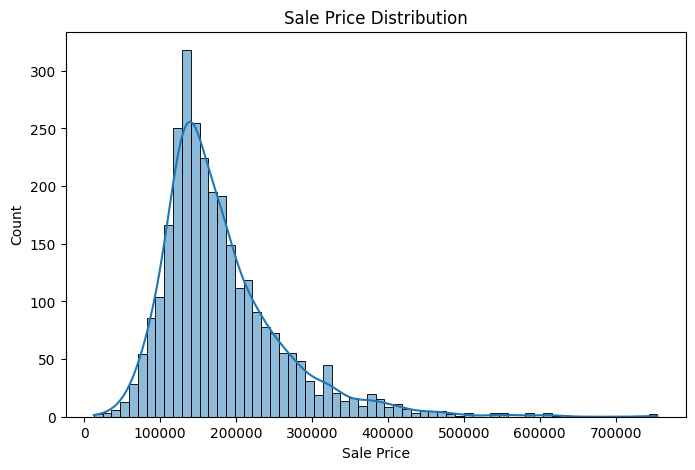

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["SalePrice"],
    kde=True
)

plt.title("Sale Price Distribution")
plt.xlabel("Sale Price")
plt.show()

In [22]:
df["SalePrice"].skew()

np.float64(1.7435000757376466)

## 09 — Log Transform Experiment

In [23]:
log_sale_price = np.log1p(
    df["SalePrice"]
)

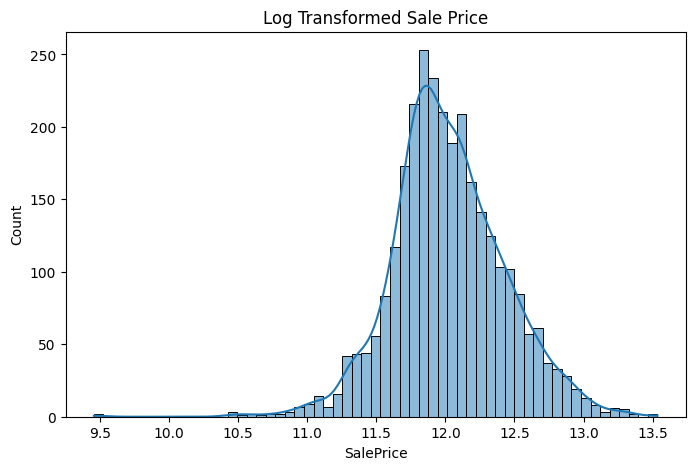

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(
    log_sale_price,
    kde=True
)

plt.title("Log Transformed Sale Price")
plt.show()

In [25]:
print(
    "Original skew:",
    df["SalePrice"].skew()
)

print(
    "Log skew:",
    log_sale_price.skew()
)

Original skew: 1.7435000757376466
Log skew: -0.014772659537224368


## 10 — Numerical Feature Analysis

In [26]:
numerical_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

In [27]:
numerical_features = [
    col for col in numerical_cols
    if col != "SalePrice"
]

In [28]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


## 11 — Outlier Analysis

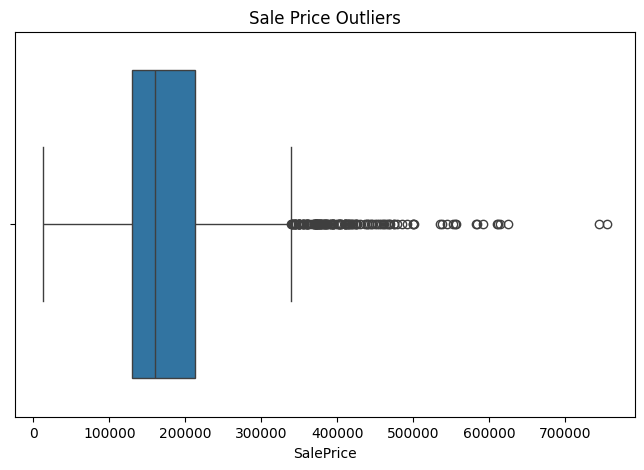

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["SalePrice"]
)

plt.title("Sale Price Outliers")
plt.show()

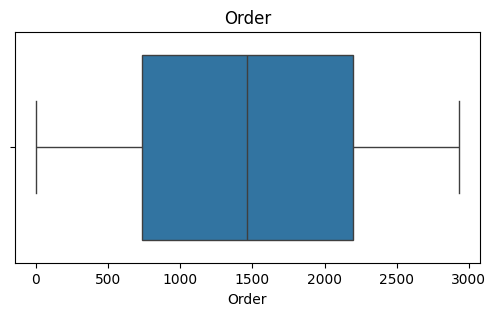

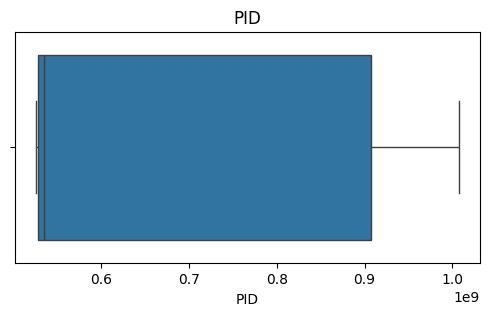

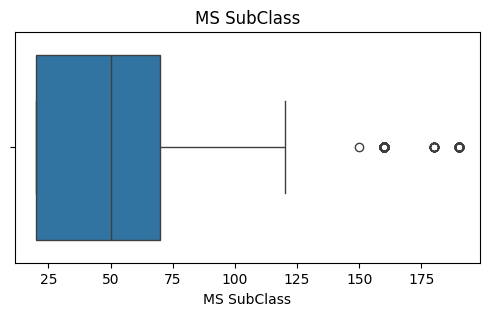

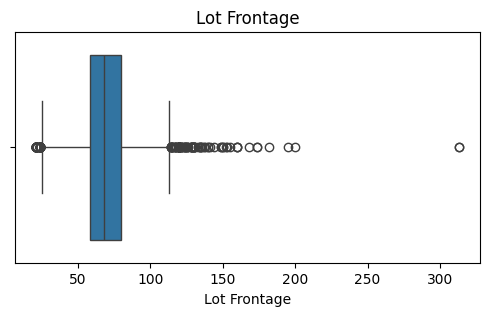

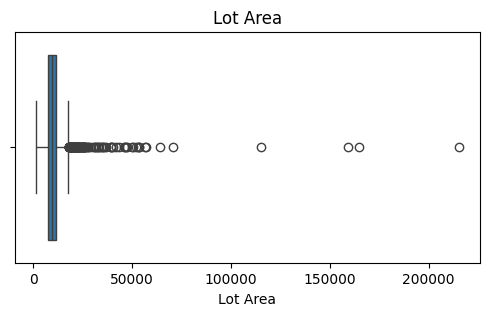

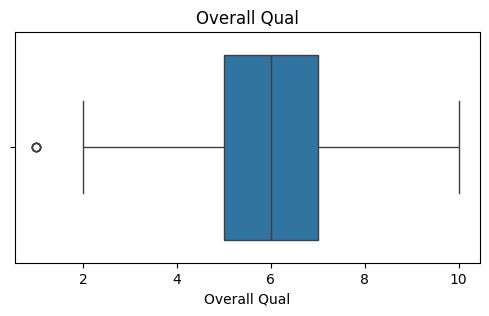

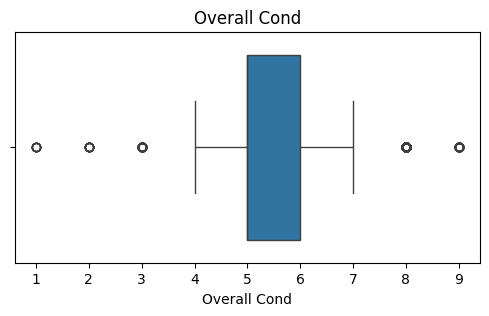

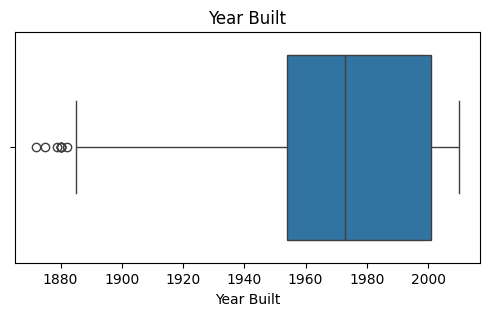

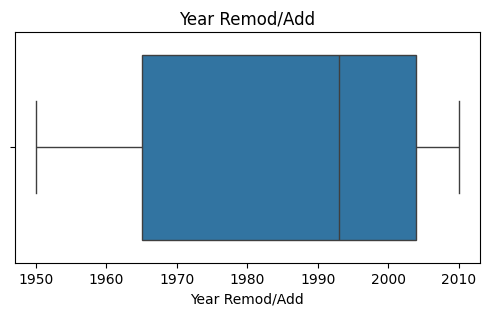

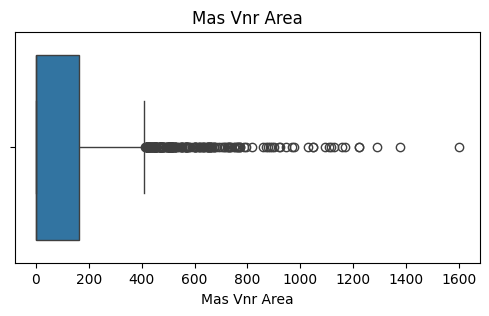

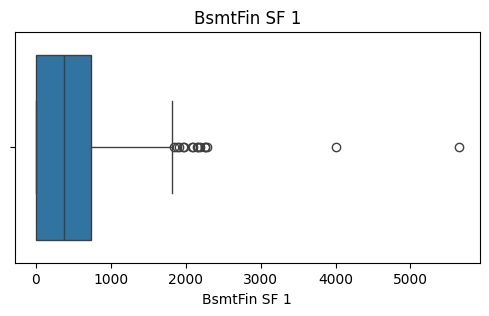

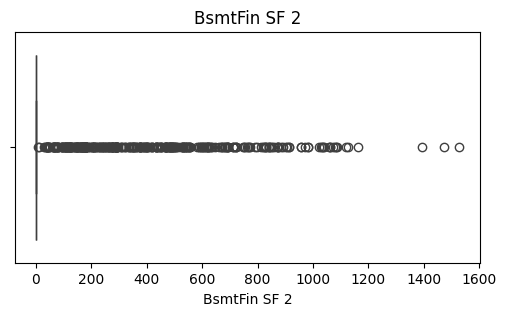

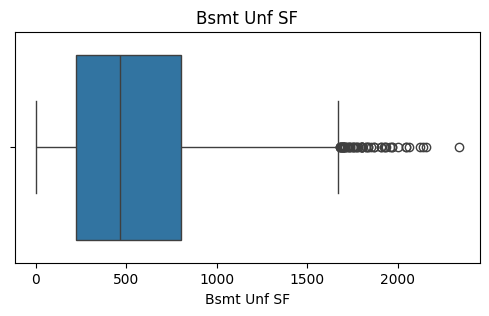

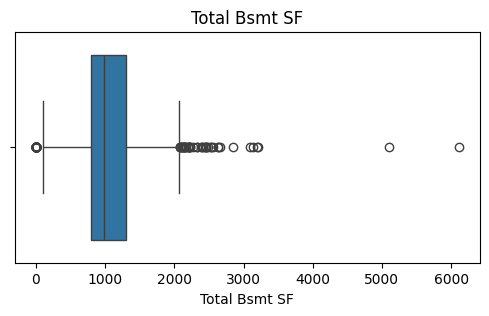

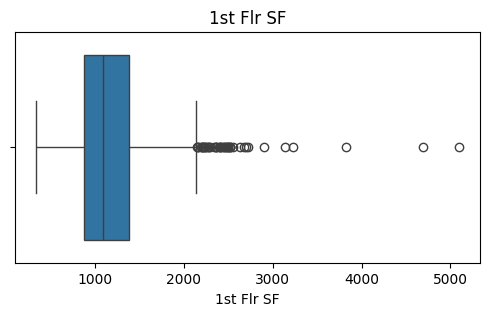

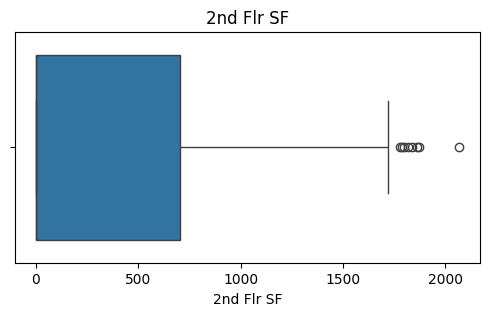

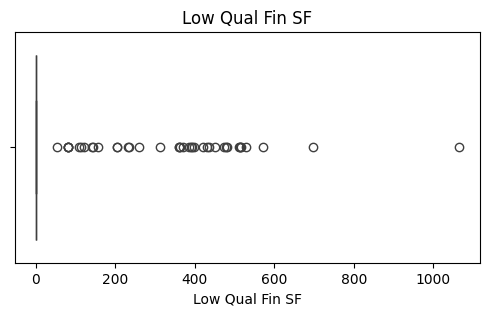

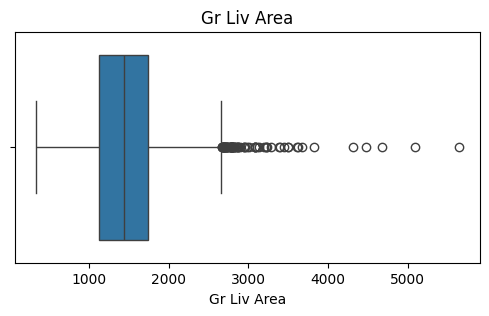

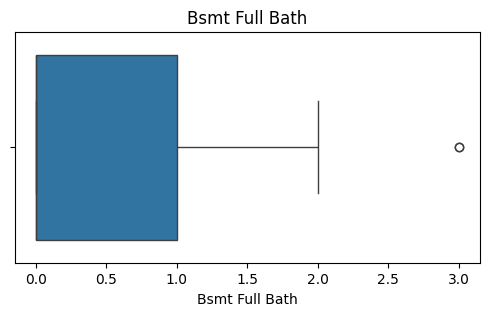

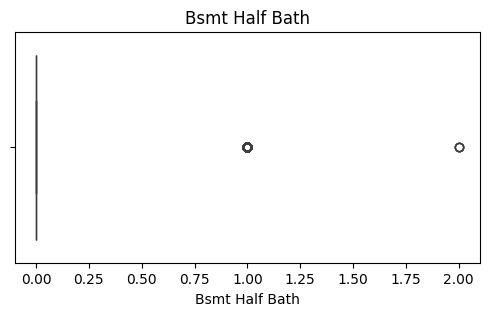

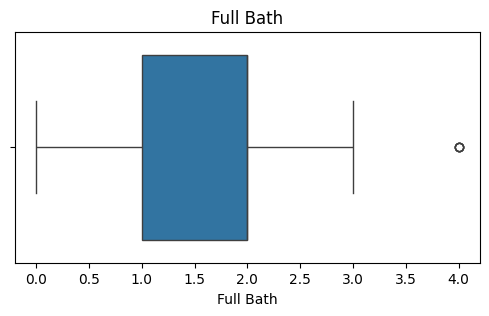

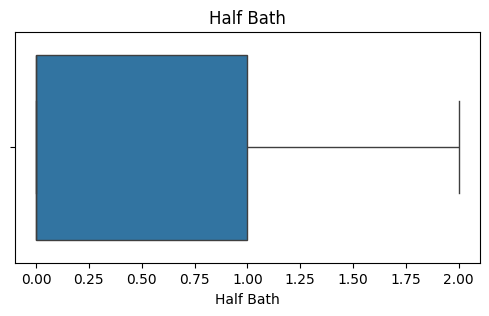

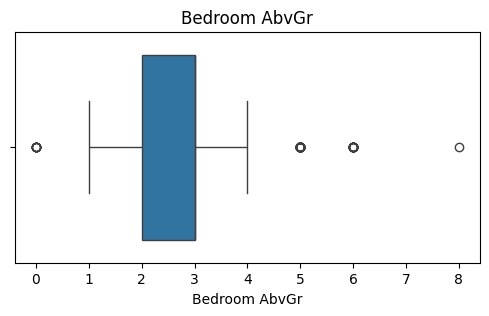

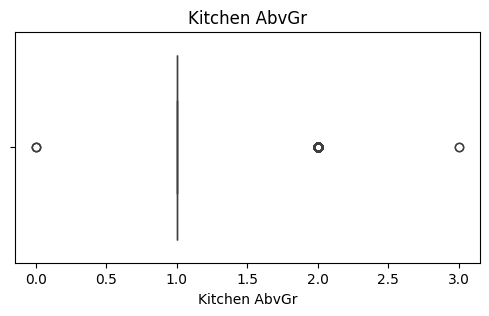

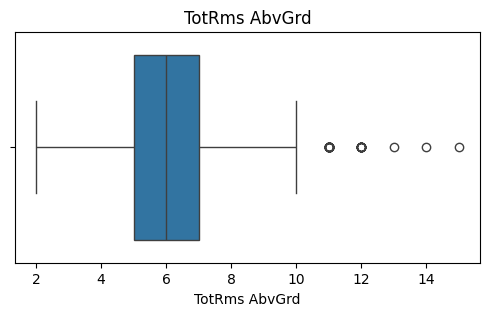

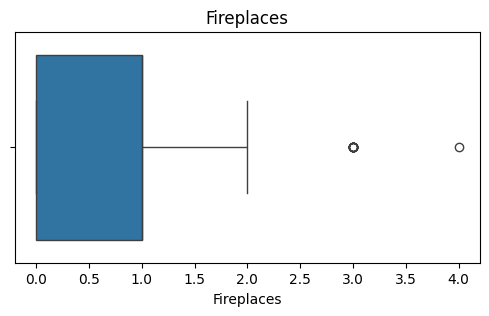

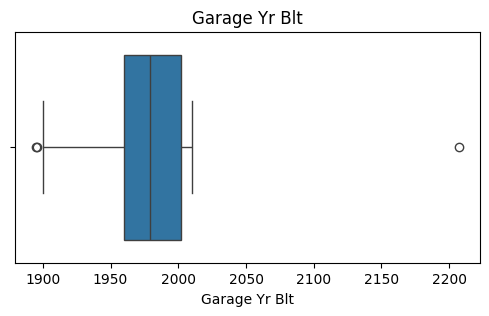

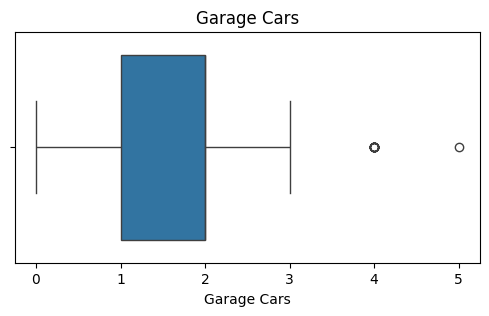

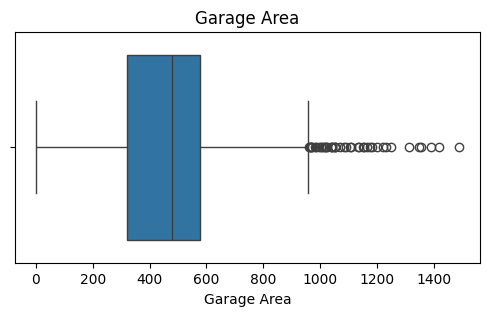

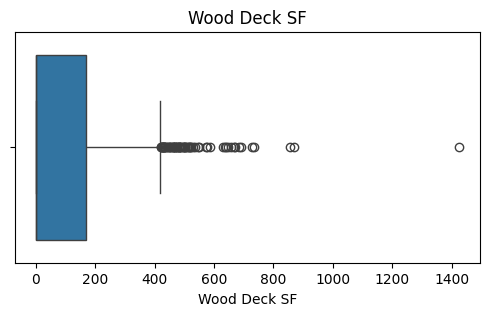

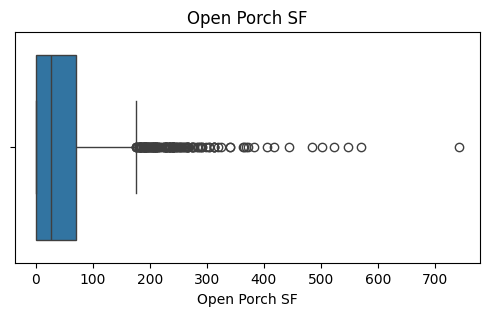

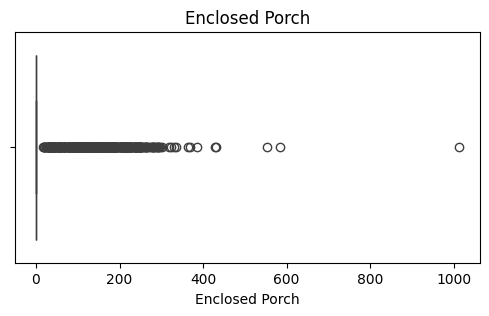

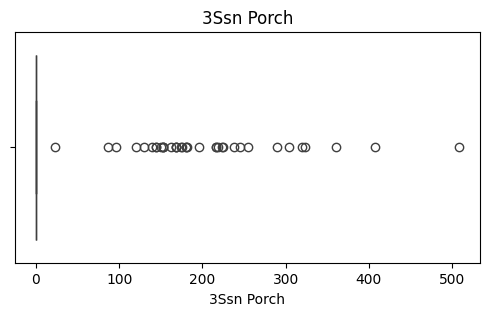

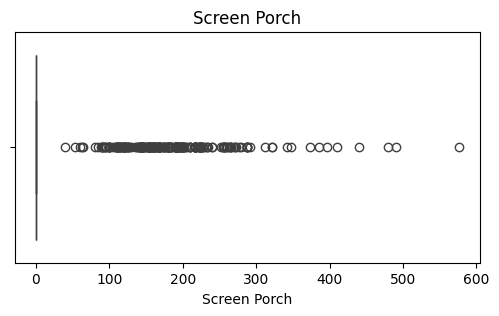

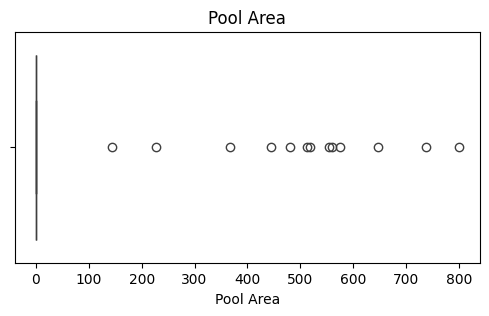

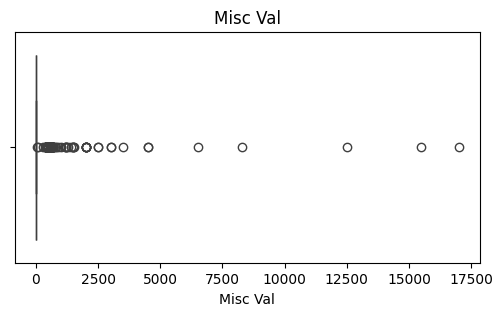

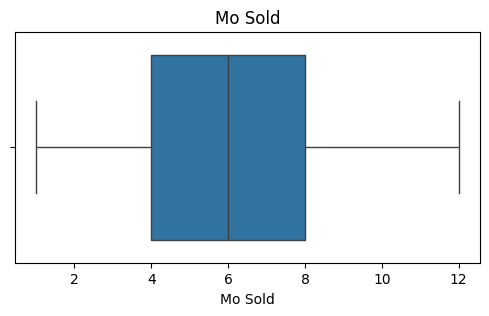

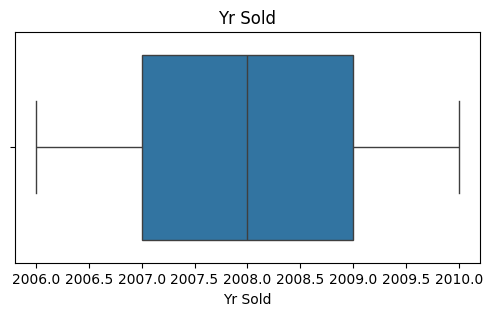

In [30]:
for col in numerical_features:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## 12 — Categorical Feature Analysis

In [31]:
categorical_features = df.select_dtypes(
    include="object"
).columns.tolist()

len(categorical_features)

43

In [32]:
categorical_cardinality = (
    df[categorical_features]
    .nunique()
    .sort_values(ascending=False)
)

categorical_cardinality

Neighborhood      28
Exterior 2nd      17
Exterior 1st      16
Sale Type         10
Condition 1        9
House Style        8
Functional         8
Roof Matl          8
Condition 2        8
MS Zoning          7
Roof Style         6
BsmtFin Type 1     6
Sale Condition     6
Heating            6
Foundation         6
Garage Type        6
BsmtFin Type 2     6
Lot Config         5
Kitchen Qual       5
Misc Feature       5
Garage Cond        5
Garage Qual        5
Exter Cond         5
Fireplace Qu       5
Bsmt Cond          5
Bldg Type          5
Bsmt Qual          5
Heating QC         5
Electrical         5
Bsmt Exposure      4
Exter Qual         4
Land Contour       4
Lot Shape          4
Mas Vnr Type       4
Pool QC            4
Fence              4
Garage Finish      3
Land Slope         3
Utilities          3
Paved Drive        3
Alley              2
Street             2
Central Air        2
dtype: int64

## 13 — Correlation With Target

In [33]:
correlation = (
    df[numerical_features + ["SalePrice"]]
    .corr()["SalePrice"]
    .sort_values(
        ascending=False
    )
)

correlation

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

In [34]:
correlation.head(15)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Name: SalePrice, dtype: float64

In [35]:
correlation.tail(15)

Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0.101697
Kitchen AbvGr     -0.119814
Enclosed Porch    -0.128787
PID               -0.246521
Name: SalePrice, dtype: float64

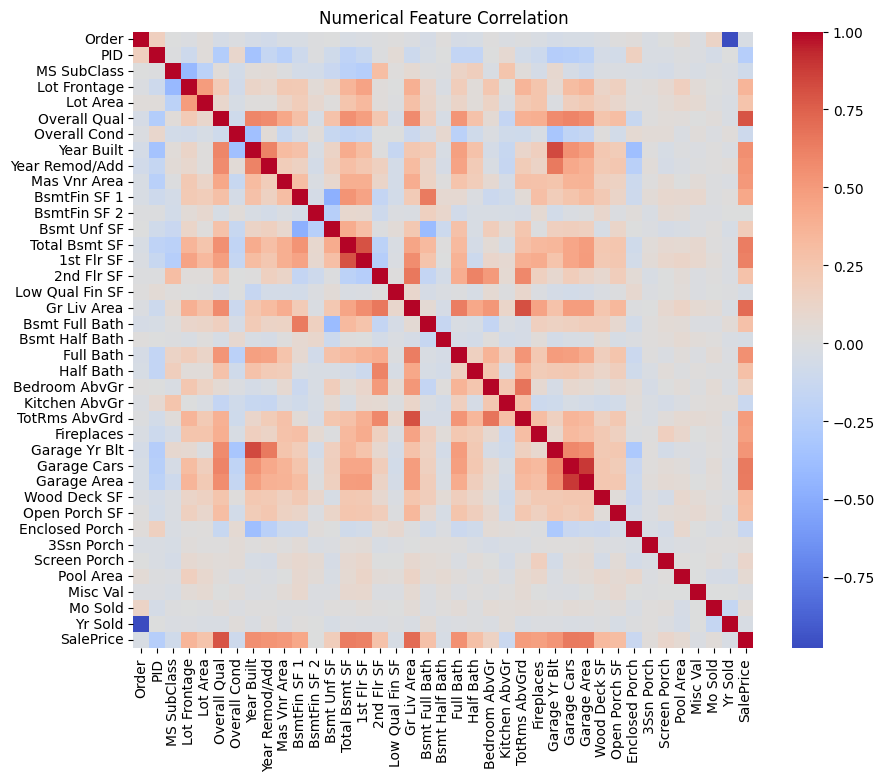

In [36]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df[numerical_features + ["SalePrice"]]
    .corr(),
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation")
plt.show()

## 14 — Important Feature Relationships

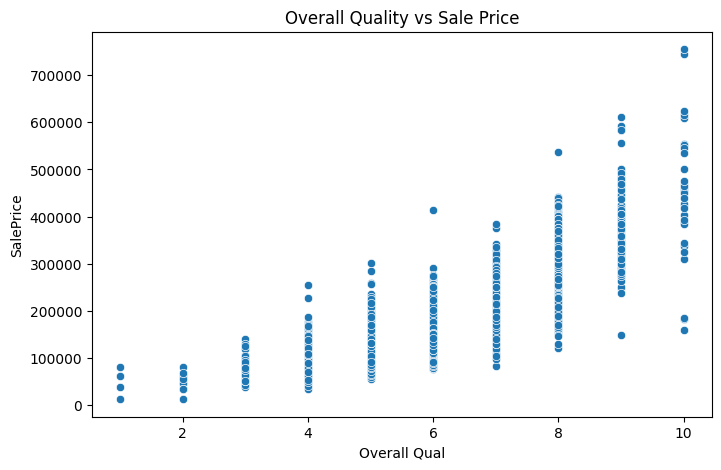

In [37]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Overall Qual",
    y="SalePrice"
)

plt.title("Overall Quality vs Sale Price")
plt.show()

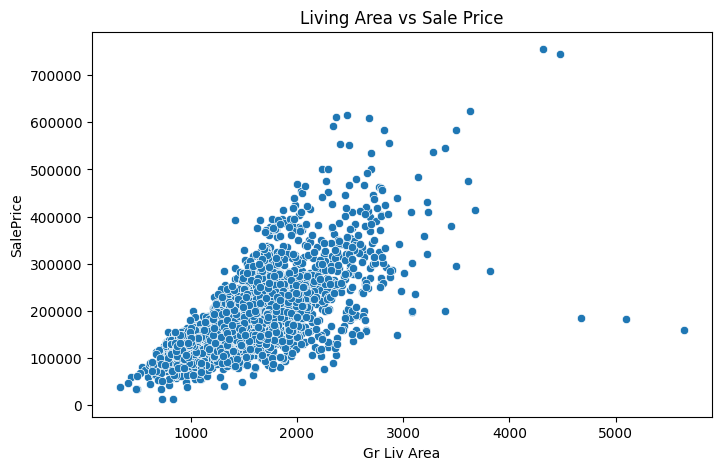

In [38]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Gr Liv Area",
    y="SalePrice"
)

plt.title("Living Area vs Sale Price")
plt.show()

## 15 — Initial Feature Engineering

#### 1.Total area

In [39]:
df["TotalSF"] = (
    df["Total Bsmt SF"].fillna(0)
    + df["1st Flr SF"].fillna(0)
    + df["2nd Flr SF"].fillna(0)
)

#### 2. Total Bathrooms

In [40]:
df["TotalBathrooms"] = (
    df["Full Bath"].fillna(0)
    + 0.5 * df["Half Bath"].fillna(0)
    + df["Bsmt Full Bath"].fillna(0)
    + 0.5 * df["Bsmt Half Bath"].fillna(0)
)

#### 3.Total porch area

In [ ]:
df["TotalPorchSF"] = (
    df["Open Porch SF"].fillna(0)
    + df["3Ssn Porch"].fillna(0)
    + df["Enclosed Porch"].fillna(0)
    + df["Screen Porch"].fillna(0)
    + df["Wood Deck SF"].fillna(0)
)

#### 4.House age

In [42]:
df["HouseAge"] = (
    df["Yr Sold"]
    - df["Year Built"]
)

#### 5.Remodeling age

In [43]:
df["RemodAge"] = (
    df["Yr Sold"]
    - df["Year Remod/Add"]
)

### Data Transformation and Model Training

#### 1.Define feature types

## 17 — Train/Test Split

In [44]:
X = df.drop(
    columns=["SalePrice"]
)

y = df["SalePrice"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [46]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'TotalSF', 'TotalBathrooms', 'TotalPorchSF', 'HouseAge', 'RemodAge']

Categorical Features:
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 

#### 2. Numerical Pipeline

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

#### 3. Categorical Pipeline

In [48]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

#### 4. ColumnTransformer

In [49]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

#### 5. Fit on Training Data

In [50]:
X_train_transformed = preprocessor.fit_transform(
    X_train
)

X_test_transformed = preprocessor.transform(
    X_test
)

#### 6. Check Shapes

In [51]:
print("Original X_train:", X_train.shape)
print("Transformed X_train:", X_train_transformed.shape)

print("Original X_test:", X_test.shape)
print("Transformed X_test:", X_test_transformed.shape)

Original X_train: (2344, 86)
Transformed X_train: (2344, 307)
Original X_test: (586, 86)
Transformed X_test: (586, 307)


#### 7. Get Feature Names

In [52]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

print(feature_names[:20])

Number of features: 307
['numerical__Order' 'numerical__PID' 'numerical__MS SubClass'
 'numerical__Lot Frontage' 'numerical__Lot Area' 'numerical__Overall Qual'
 'numerical__Overall Cond' 'numerical__Year Built'
 'numerical__Year Remod/Add' 'numerical__Mas Vnr Area'
 'numerical__BsmtFin SF 1' 'numerical__BsmtFin SF 2'
 'numerical__Bsmt Unf SF' 'numerical__Total Bsmt SF'
 'numerical__1st Flr SF' 'numerical__2nd Flr SF'
 'numerical__Low Qual Fin SF' 'numerical__Gr Liv Area'
 'numerical__Bsmt Full Bath' 'numerical__Bsmt Half Bath']


#### 8. Convert to DataFrame for Inspection

In [53]:
X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=feature_names,
    index=X_train.index
)

X_train_transformed_df.head()

,numerical__Order,numerical__PID,numerical__MS SubClass,numerical__Lot Frontage,numerical__Lot Area,numerical__Overall Qual,numerical__Overall Cond,numerical__Year Built,numerical__Year Remod/Add,numerical__Mas Vnr Area,...,categorical__Sale Type_New,categorical__Sale Type_Oth,categorical__Sale Type_VWD,categorical__Sale Type_WD,categorical__Sale Condition_Abnorml,categorical__Sale Condition_AdjLand,categorical__Sale Condition_Alloca,categorical__Sale Condition_Family,categorical__Sale Condition_Normal,categorical__Sale Condition_Partial
381,-1.284166,-0.991273,-0.871817,0.514642,0.033810,0.673941,-0.526415,0.181084,-0.381277,0.531409,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
834,-0.746674,1.018349,0.062906,-0.047047,2.307082,-0.766750,-0.526415,-0.115603,-0.814347,-0.569155,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1898,0.515781,-0.953797,0.763949,0.046568,-0.035514,-1.487095,-0.526415,-0.280430,-1.054941,-0.569155,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
678,-0.931771,-0.948378,0.763949,-0.421506,-0.363746,-1.487095,-0.526415,-0.708978,-1.632368,-0.569155,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
700,-0.905667,0.995206,3.100756,-0.281084,-0.310697,-1.487095,0.378216,-1.664971,-1.632368,-0.569155,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [54]:
X_train_transformed_df.shape

(2344, 307)

In [55]:
X_train_transformed_df.isnull().sum().sum()

np.int64(0)

#### 9. Target Transformation

In [56]:
y_train_raw = y_train.copy()
y_test_raw = y_test.copy()

In [57]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

## Model Training

#### 1.Import Models

In [58]:
!pip install xgboost

In [59]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

####  2.Define Models

In [60]:
models = {

    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(
        alpha=1.0
    ),

    "Lasso": Lasso(
        alpha=0.001,
        max_iter=10000
    ),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        objective="reg:squarederror"
    )
}

#### 3.Evaluation Function

In [61]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(
    X_train,
    X_test,
    y_train,
    y_test,
    models
):

    model_report = {}

    for model_name, model in models.items():

        print(
            f"\n{'=' * 20} "
            f"{model_name} "
            f"{'=' * 20}"
        )

        # Train
        model.fit(
            X_train,
            y_train
        )

        # Predictions
        y_pred_train = model.predict(
            X_train
        )

        y_pred_test = model.predict(
            X_test
        )

        # -------------------------
        # MAE
        # -------------------------

        train_mae = mean_absolute_error(
            y_train,
            y_pred_train
        )

        test_mae = mean_absolute_error(
            y_test,
            y_pred_test
        )

        # -------------------------
        # RMSE
        # -------------------------

        train_rmse = np.sqrt(
            mean_squared_error(
                y_train,
                y_pred_train
            )
        )

        test_rmse = np.sqrt(
            mean_squared_error(
                y_test,
                y_pred_test
            )
        )

        # -------------------------
        # R²
        # -------------------------

        train_r2 = r2_score(
            y_train,
            y_pred_train
        )

        test_r2 = r2_score(
            y_test,
            y_pred_test
        )

        # Store
        model_report[model_name] = {

            "train_mae": train_mae,
            "test_mae": test_mae,

            "train_rmse": train_rmse,
            "test_rmse": test_rmse,

            "train_r2": train_r2,
            "test_r2": test_r2
        }

    return model_report

#### 4.Train Models

In [62]:
model_report_raw = evaluate_model(
    X_train_transformed,
    X_test_transformed,
    y_train_raw,
    y_test_raw,
    models
)


==================== Linear Regression ====================

==================== Ridge ====================

==================== Lasso ====================


d:\Anaconda\envs\mlenv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.212e+11, tolerance: 1.394e+09
  model = cd_fast.enet_coordinate_descent(



==================== Decision Tree ====================

==================== Random Forest ====================

==================== Gradient Boosting ====================

==================== XGBoost ====================


In [63]:
results_raw = pd.DataFrame(
    model_report_raw
).T

results_raw

,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
Linear Regression,13130.726754,16034.553285,18972.637838,29636.767116,0.939459,0.890448
Ridge,13728.577459,16189.331659,20460.894299,28898.506033,0.929589,0.895838
Lasso,13134.763790,15909.139780,18972.970294,29336.001751,0.939457,0.892660
Decision Tree,0.000000,24611.667235,0.000000,37516.858757,1.000000,0.824446
Random Forest,5809.436542,15484.300154,9626.493043,25257.285589,0.984414,0.920433
Gradient Boosting,10877.835987,14635.774369,14952.325401,23160.477980,0.962398,0.933096
XGBoost,7169.301270,14117.928711,9602.615060,22379.464158,0.984491,0.937532


In [64]:
results_raw.sort_values(
    by="test_rmse"
)

,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
XGBoost,7169.301270,14117.928711,9602.615060,22379.464158,0.984491,0.937532
Gradient Boosting,10877.835987,14635.774369,14952.325401,23160.477980,0.962398,0.933096
Random Forest,5809.436542,15484.300154,9626.493043,25257.285589,0.984414,0.920433
Ridge,13728.577459,16189.331659,20460.894299,28898.506033,0.929589,0.895838
Lasso,13134.763790,15909.139780,18972.970294,29336.001751,0.939457,0.892660
Linear Regression,13130.726754,16034.553285,18972.637838,29636.767116,0.939459,0.890448
Decision Tree,0.000000,24611.667235,0.000000,37516.858757,1.000000,0.824446


In [65]:
results_raw.sort_values(
    by="test_r2",
    ascending=False
)

,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
XGBoost,7169.301270,14117.928711,9602.615060,22379.464158,0.984491,0.937532
Gradient Boosting,10877.835987,14635.774369,14952.325401,23160.477980,0.962398,0.933096
Random Forest,5809.436542,15484.300154,9626.493043,25257.285589,0.984414,0.920433
Ridge,13728.577459,16189.331659,20460.894299,28898.506033,0.929589,0.895838
Lasso,13134.763790,15909.139780,18972.970294,29336.001751,0.939457,0.892660
Linear Regression,13130.726754,16034.553285,18972.637838,29636.767116,0.939459,0.890448
Decision Tree,0.000000,24611.667235,0.000000,37516.858757,1.000000,0.824446


In [66]:
results_raw.sort_values(
    by="test_mae"
)

,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
XGBoost,7169.301270,14117.928711,9602.615060,22379.464158,0.984491,0.937532
Gradient Boosting,10877.835987,14635.774369,14952.325401,23160.477980,0.962398,0.933096
Random Forest,5809.436542,15484.300154,9626.493043,25257.285589,0.984414,0.920433
Lasso,13134.763790,15909.139780,18972.970294,29336.001751,0.939457,0.892660
Linear Regression,13130.726754,16034.553285,18972.637838,29636.767116,0.939459,0.890448
Ridge,13728.577459,16189.331659,20460.894299,28898.506033,0.929589,0.895838
Decision Tree,0.000000,24611.667235,0.000000,37516.858757,1.000000,0.824446


#### Experiment With Log Target

In [67]:
model_report_log = evaluate_model(
    X_train_transformed,
    X_test_transformed,
    y_train_log,
    y_test_log,
    models
)


==================== Linear Regression ====================

==================== Ridge ====================

==================== Lasso ====================

==================== Decision Tree ====================

==================== Random Forest ====================

==================== Gradient Boosting ====================

==================== XGBoost ====================


In [68]:
results_log = pd.DataFrame(
    model_report_log
).T

results_log

,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
Linear Regression,0.068307,0.079398,0.098963,0.145716,0.939135,0.885245
Ridge,0.072721,0.078161,0.105554,0.118907,0.930758,0.923586
Lasso,0.082509,0.080895,0.128880,0.120329,0.896772,0.921747
Decision Tree,0.000000,0.125272,0.000000,0.189684,1.000000,0.805545
Random Forest,0.033922,0.083076,0.052533,0.120335,0.982849,0.921739
Gradient Boosting,0.066535,0.077121,0.090595,0.112582,0.948993,0.931499
XGBoost,0.043778,0.078054,0.058050,0.110467,0.979057,0.934049


In [69]:
comparison = pd.DataFrame({
    "Raw RMSE": results_raw["test_rmse"],
    "Log RMSE": results_log["test_rmse"],
    "Raw MAE": results_raw["test_mae"],
    "Log MAE": results_log["test_mae"],
    "Raw R2": results_raw["test_r2"],
    "Log R2": results_log["test_r2"]
})

comparison

,Raw RMSE,Log RMSE,Raw MAE,Log MAE,Raw R2,Log R2
Linear Regression,29636.767116,0.145716,16034.553285,0.079398,0.890448,0.885245
Ridge,28898.506033,0.118907,16189.331659,0.078161,0.895838,0.923586
Lasso,29336.001751,0.120329,15909.139780,0.080895,0.892660,0.921747
Decision Tree,37516.858757,0.189684,24611.667235,0.125272,0.824446,0.805545
Random Forest,25257.285589,0.120335,15484.300154,0.083076,0.920433,0.921739
Gradient Boosting,23160.477980,0.112582,14635.774369,0.077121,0.933096,0.931499
XGBoost,22379.464158,0.110467,14117.928711,0.078054,0.937532,0.934049


In [70]:
best_model = models["Random Forest"]

best_model.fit(
    X_train_transformed,
    y_train_raw
)

y_pred = best_model.predict(
    X_test_transformed
)

residuals = y_test_raw - y_pred

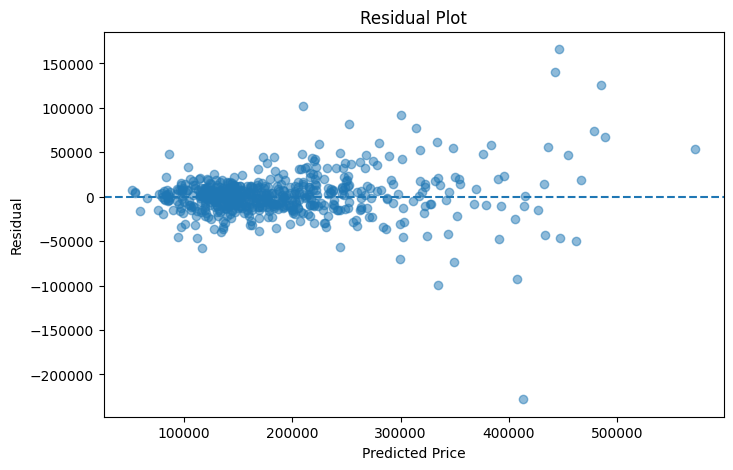

In [71]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()